# Advanced Regression, Neural Network

MLPs are explicitly listed among the most widely used neural networks for regression tasks and can learn nonlinear relationships while handling noisy data. 

For typical tabular data (like our 32-feature dataset), the best choice is usually a moderate-sized MLP (not extremely deep), trained carefully with:
* A single output neuron with linear activation,
* MSE (or MAE) as the loss,
* Appropriate regularization (dropout, L2, early stopping).

Deep neural networks (very deep MLPs or specialized architectures) are not usually “best” for simple tabular regression unless:
* You have a very large dataset, and
* The relationship is extremely complex.

Obs: In many cases, for tabular regression, gradient boosting models often outperform or match neural networks, and are easier to tune.

The packages of KERAS allow us to modify and specify parameters and functions that are fixed in sklearn. But for classification, doing this did not noticeably improve the outcome, therefore we will work with sklearn.

# Data Preparation & Partition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
#df = pd.read_csv('../dataset/cmi_internet_regression.csv')
df = pd.read_csv('cmi_internet_regression.csv')

In [4]:
X = df.drop(columns=['PCIAT-PCIAT_Total', 'sii'])
y = df['PCIAT-PCIAT_Total'].astype(int)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Variables used:")
print(num_cols)
print("Shape:", X.shape)

Variables used:
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time']
Shape: (2468, 32)


In [5]:
scaler = StandardScaler() # Very necessary! Neural networks are very sensitive to scaling.

X = scaler.fit_transform(X)

X = pd.DataFrame(
    X,
    columns=num_cols,
    index=df.index
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# Multi-Layer Perceptron (sklearn)

In [21]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [11]:
# Let's start with a simple MLPRegressor with default parameters, works fast

mlp_base = MLPRegressor(random_state=0)#, max_iter=1000) 
# Obs: if I increase max_iter (from default 200), I still get the convergence warning and worse MAE, RMSE, R2 results...
mlp_base.fit(X_train, y_train)
y_pred_base = mlp_base.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_base))
print('MSE:', mean_squared_error(y_test, y_pred_base))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_base)))
print('R2:', r2_score(y_test, y_pred_base))

MAE: 13.934493944600844
MSE: 308.9928183211752
RMSE: 17.57819155434299
R2: 0.24101538208134232


/Users/elia/Desktop/Master/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [24]:
# HYPERPARAMETER TUNING (Randomized Search)

param_distributions = {
    'hidden_layer_sizes': [(128, 64, 32), (128, 32), (64, 32), (100, 100), (50, 50)], # Model complexity.
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01], # Regularization strength.
    'learning_rate_init': [0.0005, 0.001, 0.01], # Convergence quality.
    'early_stopping': [True, False],
    'max_iter': [200, 300, 500, 1000] # To control convergence time.
}

mlp_base = MLPRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=param_distributions,
    n_iter=100, # takes 15.5 minutes
    cv=RepeatedKFold(random_state=0),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=0
)

random_search.fit(X_train, y_train)

/Users/elia/Desktop/Master/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/elia/Desktop/Master/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/elia/Desktop/Master/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/elia/Desktop/Master/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.wa

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'early_stopping': [True, False], 'hidden_layer_sizes': [(128, ...), (128, ...), ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valida

In [25]:
# EVALUATION ON TEST SET OF THE BEST MODEL

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", random_search.best_params_)

print("MAE:", mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

Best params: {'solver': 'adam', 'max_iter': 500, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (100, 100), 'early_stopping': True, 'alpha': 0.01, 'activation': 'tanh'}
MAE: 13.780205519449025
MSE: 307.45395057481454
RMSE: 17.5343648466323
R2: 0.2447953306084465


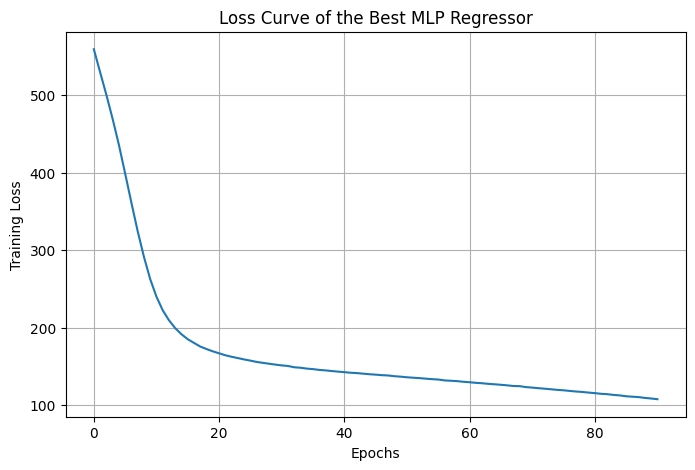

In [17]:
# LOSS CURVE OF THE BEST MODEL

plt.figure(figsize=(8,5))
plt.plot(best_model.loss_curve_)
plt.title('Loss Curve of the Best MLP Regressor')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.grid(True)
plt.show()

The loss curve helps us see: whether training converges, whether optimization is stable, and whether more epochs may help.

Typical behaviors:
* decreasing and stabilizing → good,
* oscillating strongly → learning rate too large,
* decreasing very slowly → learning rate too small,
* exploding → unstable training.

# Models Comparison Plot

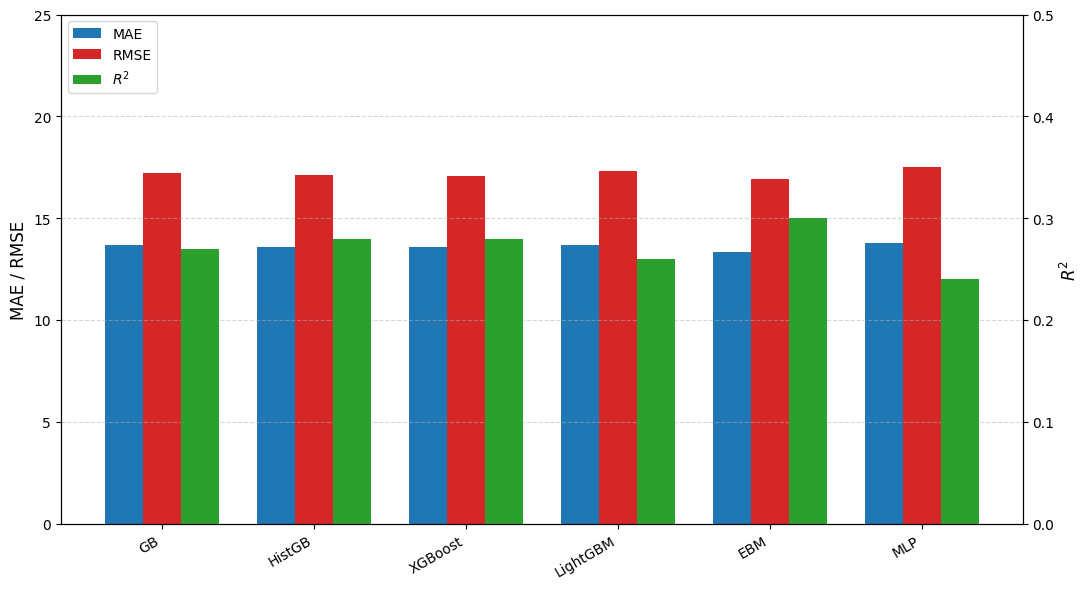

In [29]:
methods = ["GB", "HistGB", "XGBoost", "LightGBM", "EBM", "MLP"]

mae = [13.70, 13.60, 13.58, 13.70, 13.33, 13.78]
rmse = [17.22, 17.10, 17.09, 17.33, 16.91, 17.53]
r2 = [0.27, 0.28, 0.28, 0.26, 0.30, 0.24]

x = np.arange(len(methods))
width = 0.25

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

bars_mae = ax1.bar(x - width, mae, width, label='MAE', color='tab:blue')
bars_rmse = ax1.bar(x, rmse, width, label='RMSE', color='tab:red')
bars_r2 = ax2.bar(x + width, r2, width, label='$R^2$', color='tab:green')

ax1.set_ylabel('MAE / RMSE', color='black', size=12)
ax2.set_ylabel('$R^2$', color='black', size=12)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=30, ha='right')

ax1.set_ylim(0, 25)
ax2.set_ylim(0, 0.5)

ax1.grid(axis='y', linestyle='--', alpha=0.5)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()